In [1]:
import cleanup
import plotting
%load_ext autoreload
%autoreload 2

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\cleanup.py:13: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
import tkinter
from tkinter import filedialog
import scipy as scp
import scipy.stats as scpst

pd.options.mode.use_inf_as_na = True

C:\Users\hpnhp\AppData\Local\Temp\ipykernel_21556\2693178358.py:13: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [3]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df = cleanup.data_to_dataframe(filepath)

In [4]:
primary_df = primary_df[primary_df['Frame']<600]
primary_df = cleanup.calculate_distance_from_fixed_point(primary_df)
primary_df = cleanup.categorize_values(primary_df, 'X', 14, 1.5)

In [5]:
primary_df_interp = cleanup.interpolate_missing_values(primary_df)
primary_df_interp = cleanup.calculate_distance_from_fixed_point(primary_df_interp)

In [ ]:
primary_df_interp = cleanup.add_neighbor_distances(primary_df_interp)


In [69]:
primary_df_interp = cleanup.bootstrap_single_collective_conditions(primary_df_interp)

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\cleanup.py:13: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [9]:
# for cond in primary_df_interp['Condition'].unique():
#     plotting.plot_trajectory_heatmaps(primary_df_interp, cond, frame_bin_size=100, grid_size=1)

In [61]:
#Defining subdataframes for analysis

df_EA = primary_df_interp[primary_df_interp['Odour'] == 'EA']
df_1P = primary_df_interp[primary_df_interp['Odour'] == '1P']
df_PA = primary_df_interp[primary_df_interp['Odour'] == 'PA']

df_crosses = primary_df_interp[(primary_df_interp['Genotype'] == 'TrhxKir') 
                              | (primary_df_interp['Genotype'] == 'CSDxKir')
                              | (primary_df_interp['Genotype'] == 'WTxCSD')
                              | (primary_df_interp['Genotype'] == 'WTxKir')
                              | (primary_df_interp['Genotype'] == 'WTxTrh')]

In [82]:
df_single_group = primary_df_interp[(primary_df_interp['Odour'] == 'EA') 
                                    & (primary_df_interp['Genotype'] == 'WT')
                                    &(primary_df_interp['Concentration'] == '10-3')]

In [84]:
df_single_group.AvgNeighborDist.isna().sum()

18608

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Group and compute mean
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:398: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  


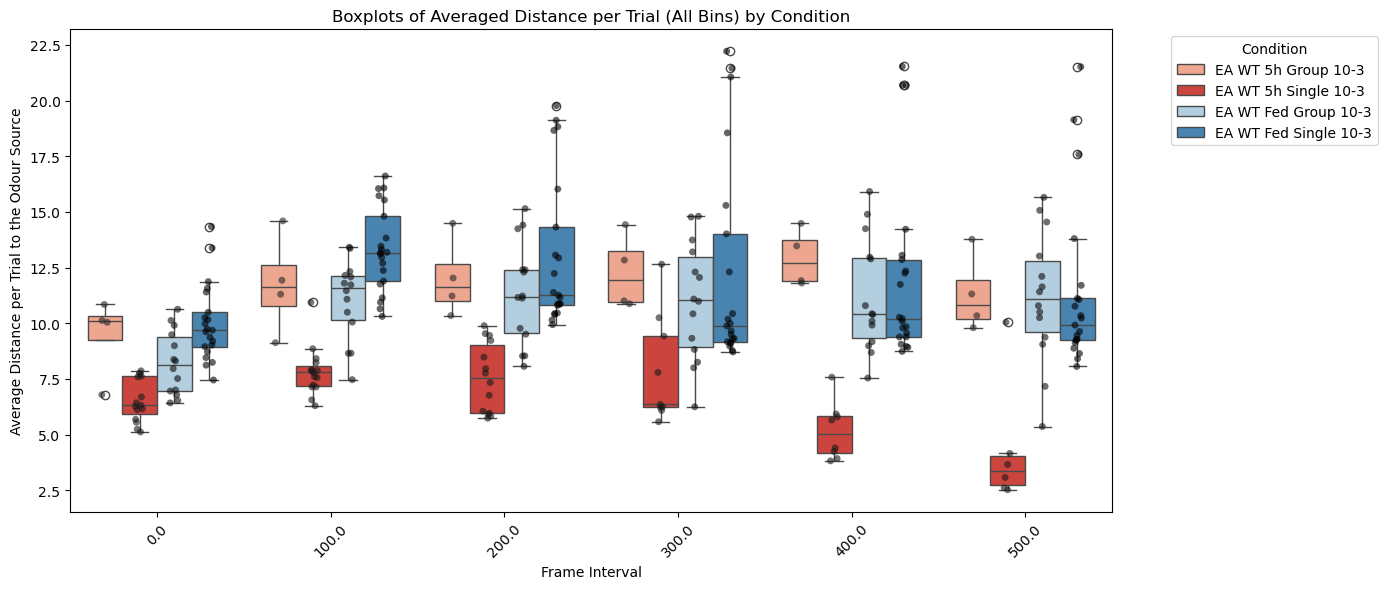

In [85]:
plotting.plot_distance_by_condition_average(df_single_group, distance_column='AvgNeighborDist')

In [14]:
df_EA_WT_Trh = df_EA[(df_EA['Genotype'] == 'WT') | (df_EA['Genotype'] == 'Trh')]

              Condition  Frame  Proportion
0  EA Trh 5h Group 10-4   12.0         0.0
1  EA Trh 5h Group 10-4   13.0         0.0
2  EA Trh 5h Group 10-4   14.0         0.0
3  EA Trh 5h Group 10-4   15.0         0.0
4  EA Trh 5h Group 10-4   16.0         0.0
Index(['Condition', 'Frame', 'Proportion'], dtype='object')


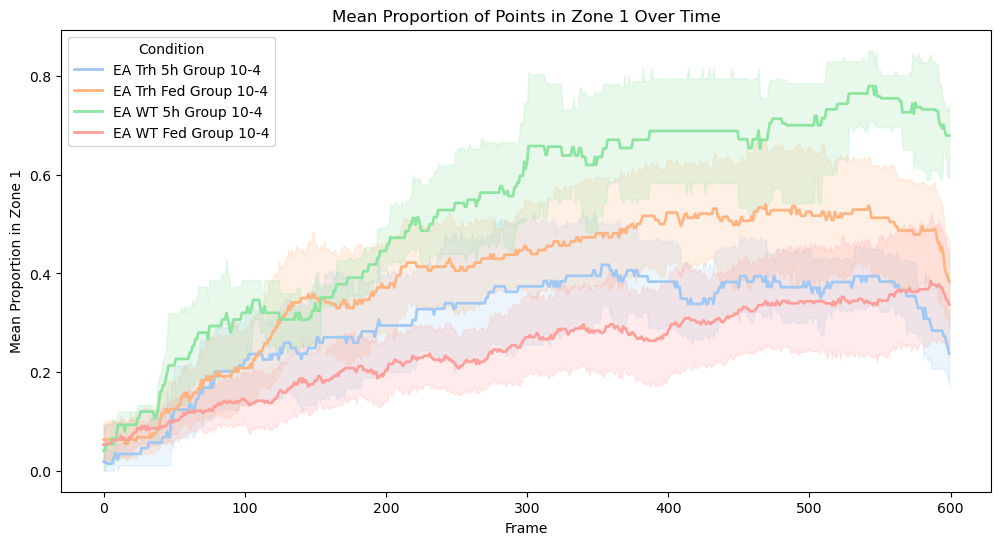

In [20]:
plotting.plot_zone_1_over_time(df_EA_WT_Trh[(df_EA_WT_Trh['Collective'] == 'Group') & (df_EA_WT_Trh['Concentration'] == '10-4')])

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Group and compute mean
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:398: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  


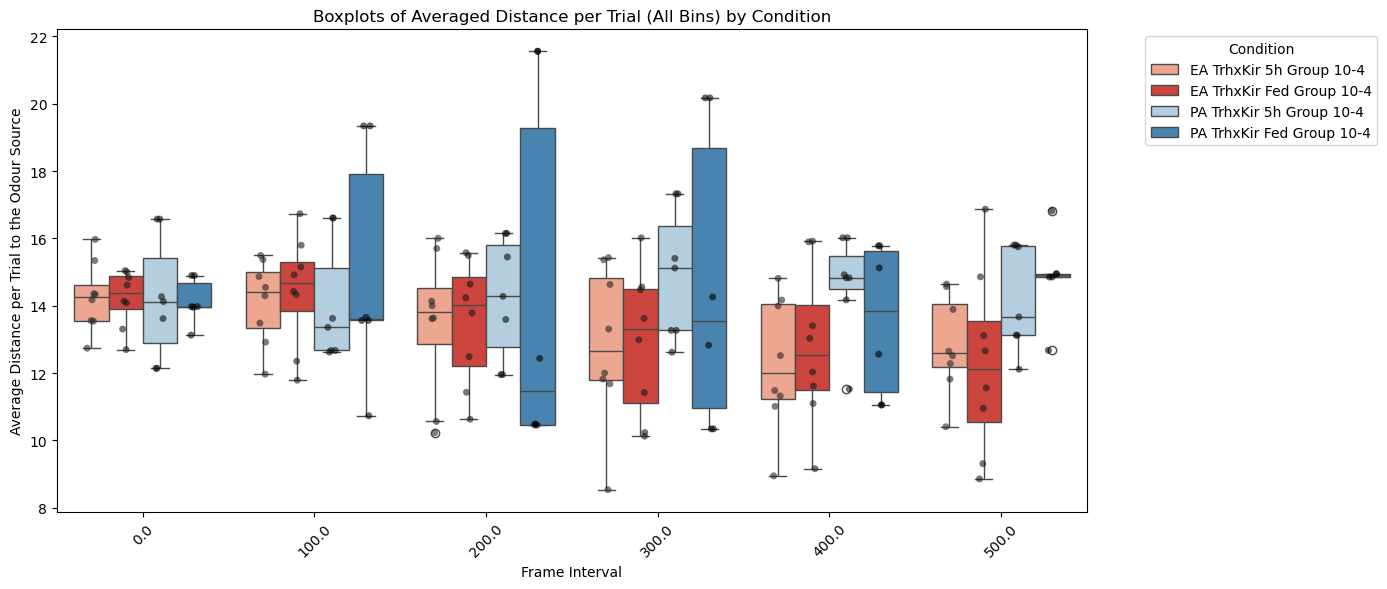

In [27]:
plotting.plot_distance_by_condition_average(df_crosses[df_crosses['Genotype'] == 'TrhxKir'], bin_size=100)

In [36]:
df_crosses_pa_fed = df_crosses[(df_crosses['Odour'] == 'PA') & (df_crosses['Starvation'] == 'Fed')]

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Group and compute mean
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:398: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  


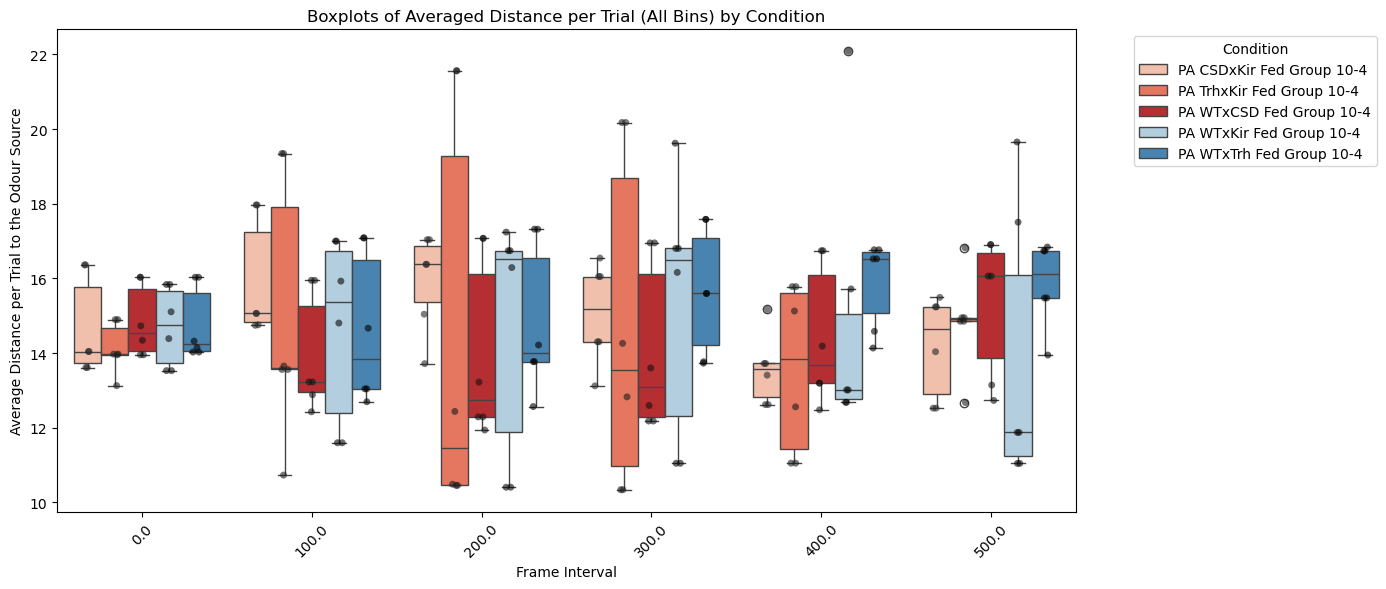

In [37]:
plotting.plot_distance_by_condition_average(df_crosses_pa_fed, bin_size=100)

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Group and compute mean
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:398: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  


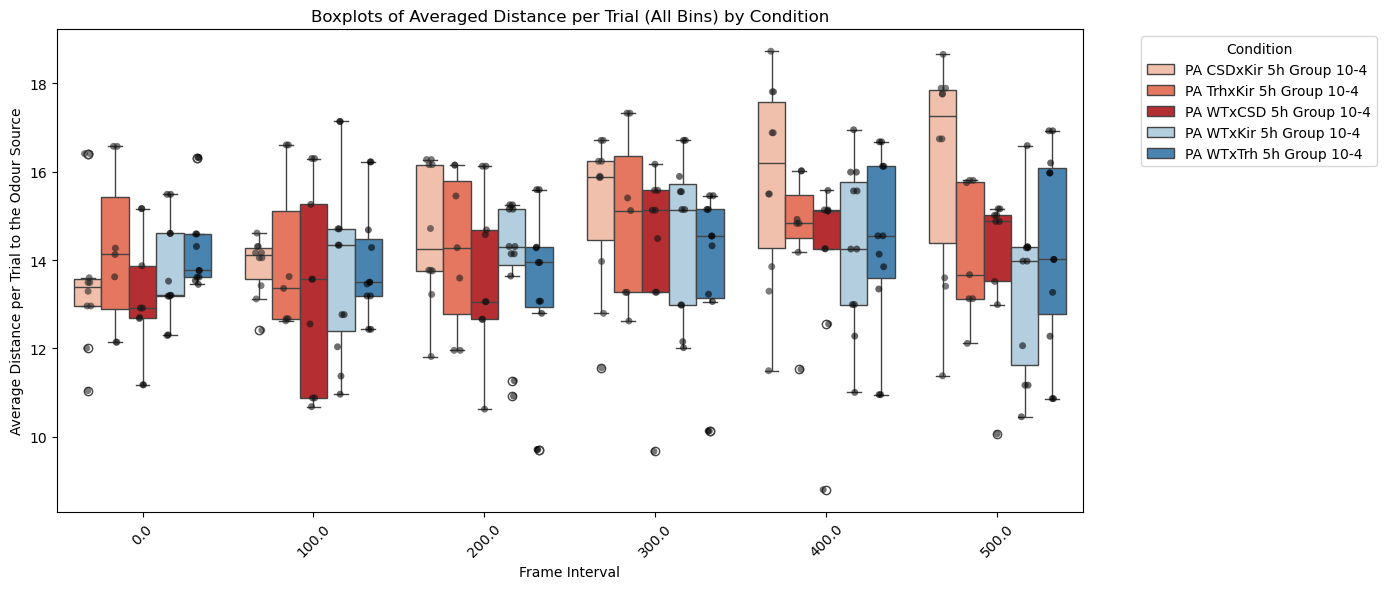

In [40]:
df_crosses_pa_5h = df_crosses[(df_crosses['Odour'] == 'PA') & (df_crosses['Starvation'] == '5h')]
plotting.plot_distance_by_condition_average(df_crosses_pa_5h, bin_size=100)

In [38]:
df_crosses_ea_fed = df_crosses[(df_crosses['Odour'] == 'EA') & (df_crosses['Starvation'] == 'Fed')]

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:374: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Group and compute mean
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:398: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  


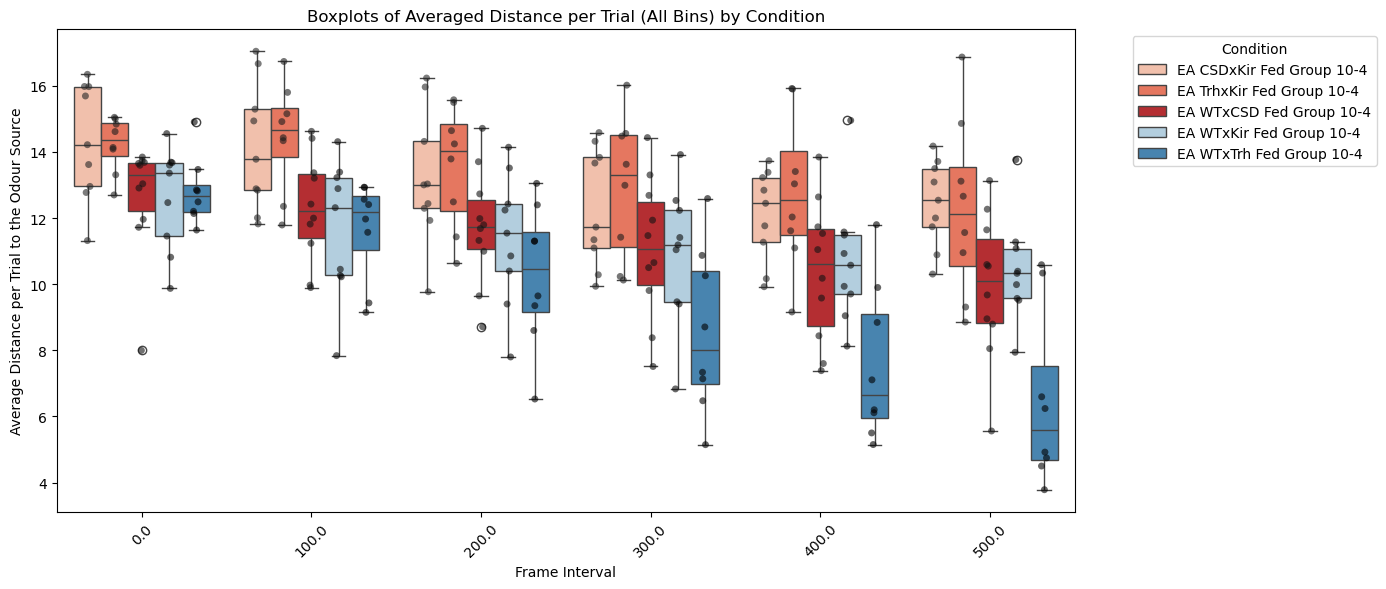

In [39]:
plotting.plot_distance_by_condition_average(df_crosses_ea_fed, bin_size=100)

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:610: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:610: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.



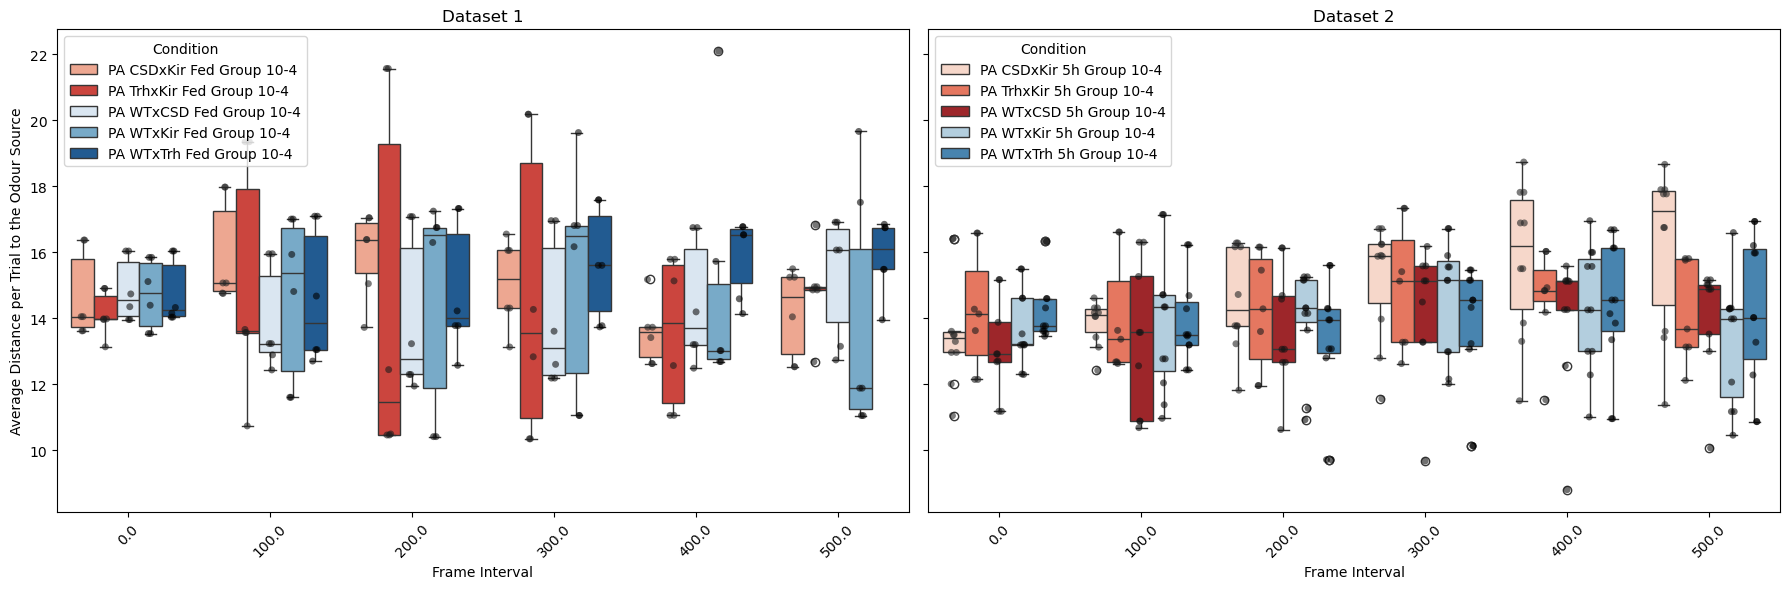

In [42]:
plotting.plot_two_distance_by_condition_averages(df_crosses_pa_fed, df_crosses_pa_5h)